# Test Scripts


In [42]:
## imports and filtering out warnings

import sys
import os
import warnings
import matplotlib.pyplot as plt

os.environ["MKL_THREADING_LAYER"] = "GNU"
sys.path.append('..')
warnings.filterwarnings("ignore", category=FutureWarning)

%load_ext autoreload
%autoreload 2

from data.loaders import load_era5_vars, load_sentinel1_bands, load_sentinel2_bands
from data.aggregator import aggregate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
## Grab file paths 
era5_dir = '/Users/asankoh/WildfirePrediction/DOME_fire/ERA5_NV_35N116W_20200815.grib'
s1_post_dir = '/Users/asankoh/WildfirePrediction/DOME_fire/S1A_IW_GRDH_1SDV_20200822T134401_20200822T134426_034020_03F2D2_FC8A_COG.SAFE'
s1_pre_dir = '/Users/asankoh/WildfirePrediction/DOME_fire/S1A_IW_GRDH_1SDV_20200729T134400_20200729T134425_033670_03E6FE_381F_COG.SAFE'
s2_post_dir = '/Users/asankoh/WildfirePrediction/DOME_fire/S2A_MSIL2A_20200823T181931_N0500_R127_T11SPV_20230318T064036.SAFE' 
s2_pre_dir = '/Users/asankoh/WildfirePrediction/DOME_fire/S2B_MSIL2A_20200729T181919_N0500_R127_T11SPV_20230326T125007.SAFE'

## Testing Loaders

In [44]:
# load era5 data and check variables
era5_processed_data = load_era5_vars(era5_dir)
print(era5_processed_data['tp'][10])


<xarray.DataArray 'tp' (longitude: 21, valid_time: 1488)> Size: 125kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * longitude   (longitude) float64 168B -118.0 -117.8 -117.5 ... -113.2 -113.0
  * valid_time  (valid_time) object 12kB MultiIndex
  * time        (valid_time) datetime64[ns] 12kB 2020-06-30T18:00:00 ... 2020...
  * step        (valid_time) timedelta64[ns] 12kB 06:00:00 07:00:00 ... 05:00:00
    number      int64 8B 0
    surface     float64 8B 0.0
    latitude    float64 8B 34.5
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      273
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GR

In [45]:
# load s1 data and visualize the bands

vh_band_dir = s1_pre_dir + '/measurement/s1a-iw-grd-vh-20200729t134400-20200729t134425-033670-03e6fe-002-cog.tiff'
vv_band_dir = s1_pre_dir + '/measurement/s1a-iw-grd-vv-20200729t134400-20200729t134425-033670-03e6fe-001-cog.tiff'
vh_cal_dir = s1_pre_dir + '/annotation/calibration/calibration-s1a-iw-grd-vh-20200729t134400-20200729t134425-033670-03e6fe-002-cog.xml'
vv_cal_dir = s1_pre_dir + '/annotation/calibration/calibration-s1a-iw-grd-vv-20200729t134400-20200729t134425-033670-03e6fe-001-cog.xml'
annotation_file = s1_pre_dir + '/annotation/s1a-iw-grd-vh-20200729t134400-20200729t134425-033670-03e6fe-002-cog.xml'
output_dir = '/Users/asankoh/WildfirePrediction/DEM/'

s1_pre_data = load_sentinel1_bands(vh_band_dir, vv_band_dir, vh_cal_dir, vv_cal_dir, annotation_file, output_dir)

KeyboardInterrupt: 

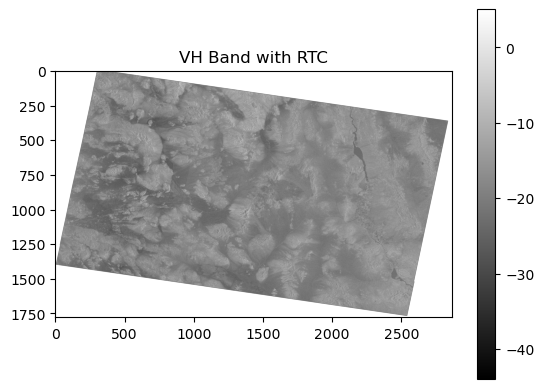

In [ ]:
# plot the bands 

vh_band = s1_pre_data[0]["vh_band"]
vv_band = s1_pre_data[0]["vv_band"]

vh_transform = s1_pre_data[1]
vh_shape = s1_pre_data[2]
s1_crs = s1_pre_data[3]

plt.title("VH Band with RTC")
plt.imshow(vh_band, cmap='gray')
plt.colorbar()
plt.show()

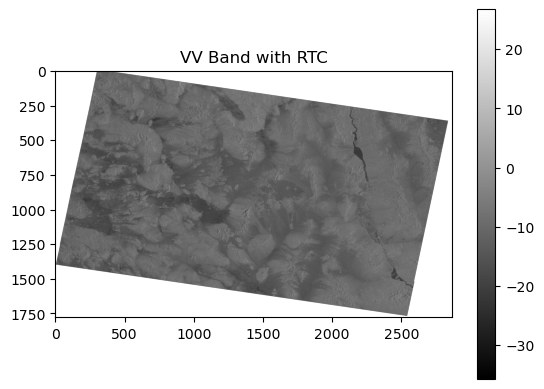

In [ ]:
plt.title("VV Band with RTC")
plt.imshow(vv_band, cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
print(vh_transform)
print(vh_shape)

| 0.00, 0.00,-117.01|
| 0.00,-0.00, 36.06|
| 0.00, 0.00, 1.00|
(1779, 2866)


In [ ]:
# retrieve band directories and perform calculations

red_band_path = s2_pre_dir + '/GRANULE/L2A_T11SPV_A017742_20200729T183235/IMG_DATA/R10m/T11SPV_20200729T181919_B04_10m.jp2'
green_band_path = s2_pre_dir + '/GRANULE/L2A_T11SPV_A017742_20200729T183235/IMG_DATA/R10m/T11SPV_20200729T181919_B03_10m.jp2'
nir_band_path = s2_pre_dir + '/GRANULE/L2A_T11SPV_A017742_20200729T183235/IMG_DATA/R10m/T11SPV_20200729T181919_B08_10m.jp2'
swir_band_path = s2_pre_dir + '/GRANULE/L2A_T11SPV_A017742_20200729T183235/IMG_DATA/R20m/T11SPV_20200729T181919_B11_20m.jp2'
scl_band_path = s2_pre_dir + '/GRANULE/L2A_T11SPV_A017742_20200729T183235/IMG_DATA/R20m/T11SPV_20200729T181919_SCL_20m.jp2'

s2_pre_data = load_sentinel2_bands(red_band_path, green_band_path, nir_band_path, swir_band_path, scl_band_path)

In [ ]:
# downsample for testing purposes 

from rasterio.transform import Affine
nir_transform = s2_pre_data[1] * Affine.scale(10, 10)

for key in s2_pre_data[0]["filtered_bands"]:
    s2_pre_data[0]["filtered_bands"][key] = s2_pre_data[0]["filtered_bands"][key][::10, ::10]
for key in s2_pre_data[0]["indices"]:
    s2_pre_data[0]["indices"][key] = s2_pre_data[0]["indices"][key][::10, ::10]

nir_shape = s2_pre_data[0]["filtered_bands"]["nir"].shape

print(nir_shape)
print(nir_transform)



(1098, 1098)
| 100.00, 0.00, 600000.00|
| 0.00,-100.00, 4000020.00|
| 0.00, 0.00, 1.00|


In [ ]:
indices = s2_pre_data[0]["indices"]
bands = s2_pre_data[0]["filtered_bands"]
s2_crs = s2_pre_data[3]

nbr = indices["nbr"]
ndvi = indices["ndvi"]

In [ ]:
# for testing purposes only 
s2_pre_data = s2_pre_data[0], nir_transform, nir_shape, s2_crs


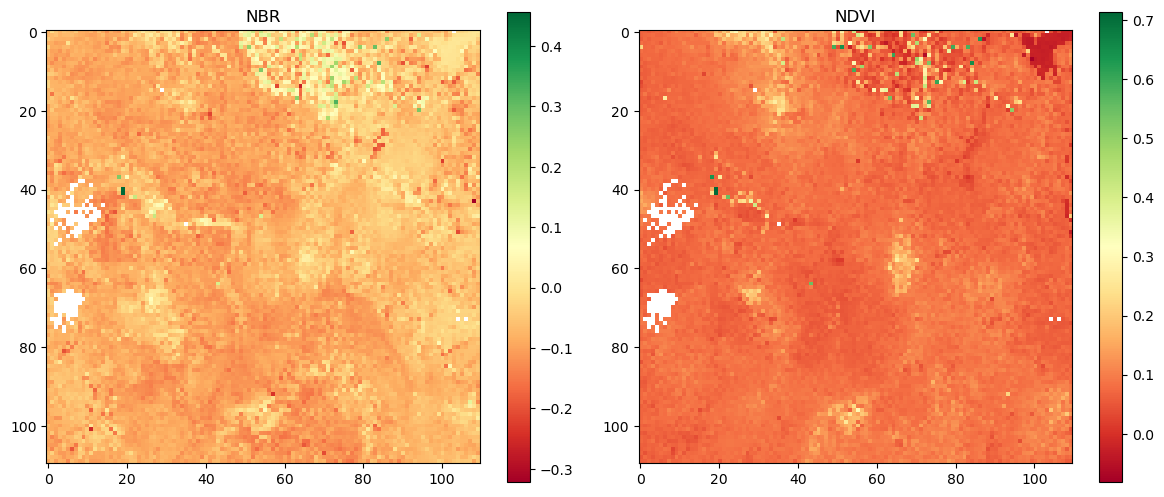

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.set_title("NBR")
ax2.set_title("NDVI")
im1 = ax1.imshow(nbr[::10, ::10], cmap='RdYlGn')
im2 = ax2.imshow(ndvi[::10, ::10], cmap='RdYlGn')
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

## Testing Aggregators

In [ ]:
tiles = aggregate(s1_pre_data, s2_pre_data, era5_processed_data)

Sentinel-1 and Sentinel-2 pixels vectorized and binned.


Tiling statistics from each source according to ERA5 grid boundaries.: 100%|██████████| 126/126 [04:14<00:00,  2.02s/it]


In [ ]:
# print s2_stats for each key
for i in range(len(tiles)):
    key = list(tiles.keys())[i]
    print(tiles[key]['s2_stats'])

{'red_mean': 2861.966417910448, 'red_std': 438.5743867765228, 'green_mean': 2364.6102861978766, 'green_std': 340.2227105584588, 'nir_mean': 3379.0631250961687, 'nir_std': 520.1720042440729, 'swir_mean': 3864.9781120172333, 'swir_std': 544.3502825421346, 'ndvi_mean': 0.08231670261238364, 'ndvi_std': 0.02073554184759469, 'nbr_mean': -0.0678864440295969, 'nbr_std': 0.03524071668970224}
None
{'red_mean': 3039.5923133096267, 'red_std': 339.2111383261593, 'green_mean': 2577.3392176784355, 'green_std': 287.4590799340221, 'nir_mean': 3553.48058483617, 'nir_std': 383.6861147188491, 'swir_mean': 3945.2791783083567, 'swir_std': 486.79506038317186, 'ndvi_mean': 0.07807720652794624, 'ndvi_std': 0.016632989173096625, 'nbr_mean': -0.05127041920815644, 'nbr_std': 0.028573912625773107}
{'red_mean': 3763.033053745214, 'red_std': 646.1802253775024, 'green_mean': 3140.8491685419526, 'green_std': 503.6120694657124, 'nir_mean': 4343.037788233919, 'nir_std': 745.1295357329614, 'swir_mean': 5180.5205015051, '

## Testing Dataset

In [53]:
from model import dataset
from model.augmentation import TileAugmenter
import numpy as np
import torch

In [54]:
ds = dataset(tiles)
print(f'length: {len(ds)}')

x_spatial, x_temporal = ds[0]
print(x_spatial)
print(x_spatial.shape)
print(x_temporal.shape)

length: 126
tensor([-1.8889e+01,  3.5328e+00, -1.1994e+01,  3.7121e+00,  2.8620e+03,
         4.3857e+02,  2.3646e+03,  3.4022e+02,  3.3791e+03,  5.2017e+02,
         3.8650e+03,  5.4435e+02,  8.2317e-02,  2.0736e-02, -6.7886e-02,
         3.5241e-02])
torch.Size([16])
torch.Size([5])


## Testing Tile Augmentor

In [55]:
s1_keys = ['vh_band_mean', 'vh_band_std', 'vv_band_mean', 'vv_band_std']
s2_keys = ['red_mean', 'red_std', 'green_mean', 'green_std', 'nir_mean', 'nir_std',
           'swir_mean', 'swir_std', 'ndvi_mean', 'ndvi_std', 'nbr_mean', 'nbr_std']
era5_keys = ['u10', 'v10', 'd2m', 't2m', 'tp']

spatial_keys = s1_keys + s2_keys   # matches x_spatial concat order in dataset.py
temporal_keys = era5_keys          # matches x_temporal order in dataset.py

# dataset-wide std per feature, computed across all tiles (same pattern as ds.statistic_means)
feature_stds = {}
for key in s1_keys:
    vals = [t["s1_stats"][key] for _, t in ds.data_list if t["s1_stats"] is not None and t["s1_stats"][key] is not None]
    feature_stds[key] = np.std(vals) if len(vals) > 1 else 1.0
for key in s2_keys:
    vals = [t["s2_stats"][key] for _, t in ds.data_list if t["s2_stats"] is not None and t["s2_stats"][key] is not None]
    feature_stds[key] = np.std(vals) if len(vals) > 1 else 1.0
for key in era5_keys:
    vals = [t["era5_stats"][key] for _, t in ds.data_list if t["era5_stats"] is not None and t["era5_stats"][key] is not None]
    feature_stds[key] = np.std(vals) if len(vals) > 1 else 1.0

augmenter = TileAugmenter(feature_stds, seed=42)  # seed must be an int, not None -- torch_gen.manual_seed(None) will throw

x_spatial_jittered, x_temporal_jittered = augmenter.jitter(x_spatial, x_temporal, spatial_keys, temporal_keys)
print(x_spatial_jittered)
print(x_temporal_jittered)

tensor([-1.8875e+01,  3.5128e+00, -1.1957e+01,  3.7306e+00,  2.8324e+03,
         4.2507e+02,  2.3661e+03,  3.3780e+02,  3.3787e+03,  5.1001e+02,
         3.8880e+03,  5.5440e+02,  8.2368e-02,  2.1814e-02, -6.7390e-02,
         3.4587e-02])
tensor([9.6215e-01, 3.3395e-01, 2.7475e+02, 3.0615e+02, 1.6267e-06])


In [56]:
impute_value_spatial = torch.tensor([ds.statistic_means[f"mean_{k}"] for k in spatial_keys]).float()
impute_value_temporal = torch.tensor([ds.statistic_means[f"mean_{k}"] for k in temporal_keys]).float()

x_spatial_dropped, x_temporal_dropped = augmenter.dropout(x_spatial, x_temporal, impute_value_spatial, impute_value_temporal)
print(x_spatial_dropped)
print(x_temporal_dropped)

tensor([-1.8889e+01,  3.5328e+00, -1.1994e+01,  3.7121e+00,  2.8620e+03,
         4.3857e+02,  2.3646e+03,  3.4022e+02,  3.3791e+03,  5.2017e+02,
         3.8650e+03,  5.4435e+02,  8.2317e-02,  2.0736e-02, -6.7886e-02,
         3.5241e-02])
tensor([9.4860e-01, 3.6590e-01, 2.7466e+02, 3.0616e+02, 1.6535e-06])


## Testing Forward Pass

In [46]:
from model.architecture import WildfireModel

In [57]:
model = WildfireModel(x_spatial.shape[0], x_temporal.shape[0], 32, 2, 1)
fpass = model(x_spatial, x_temporal)

head1, head2, head3, weights = fpass
print(head1.shape, head1.item())
print(head2.shape, head2.item())
print(head3.shape, head3.item())
print(weights)

print(x_spatial)

torch.Size([1, 1]) 5.888108283667566e-21
torch.Size([1, 1]) 2.752192258664971e-30
torch.Size([1, 1]) 0.0
tensor([[[1.]]], grad_fn=<MeanBackward1>)
tensor([-1.8889e+01,  3.5328e+00, -1.1994e+01,  3.7121e+00,  2.8620e+03,
         4.3857e+02,  2.3646e+03,  3.4022e+02,  3.3791e+03,  5.2017e+02,
         3.8650e+03,  5.4435e+02,  8.2317e-02,  2.0736e-02, -6.7886e-02,
         3.5241e-02])


/Users/asankoh/opt/anaconda3/envs/wildfire-pred/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
